# (09) Kyoto — save color

**Motivation**: both $16 \times 16$, and $32 \times 32$, low contrast removed (bottom $10\%$). <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-vae/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-vae/figs')
tmp_dir = os.path.join(git_dir, 'jb-vae/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.fighelper import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from figures.imgs import plot_weights

import scipy.io as sio

from utils.imgproc import (
    do_process, xtract_patches,
    do_fft, compute_fftfreq,
    EyeDataset,
)


device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: mach

## Load KYOTO images

In [3]:
root = 'Datasets/Kyoto'
root = add_home(root)

raw_dir = pjoin(root, 'raw')
files = sorted(os.listdir(raw_dir), key=alphanum_sort_key)
len(files)

62

### get color imgs

In [4]:
imgs_color = collections.defaultdict(list)

for f in files:
    data_dict = sio.loadmat(pjoin(raw_dir, f))
    img_dim = np.asarray(data_dict['OL']).shape

    img = np.zeros([3, img_dim[0], img_dim[1]])
    img[0] = np.asarray(data_dict['OL'])
    img[1] = np.asarray(data_dict['OM'])
    img[2] = np.asarray(data_dict['OS'])

    imgs_color[img_dim].append(img)

imgs_color = {k: np.stack(v) for k, v in imgs_color.items()}
print({k: v.shape for k, v in imgs_color.items()})

{(500, 640): (50, 3, 500, 640), (640, 500): (12, 3, 640, 500)}

In [5]:
x2p = imgs_color[(500, 640)][14]
x2p = np.transpose(x2p, (1, 2, 0))
x2p_bw = x2p.mean(-1)

x2p.shape, x2p_bw.shape

((500, 640, 3), (500, 640))

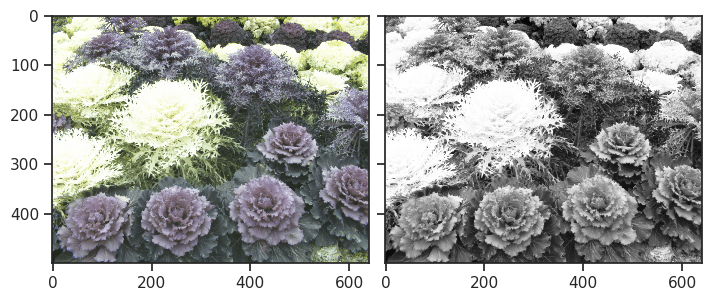

In [6]:
fig, axes = create_figure(1, 2, (7, 3), sharex='all', sharey='all')

axes[0].imshow(x2p)
axes[1].imshow(x2p_bw, cmap='Greys_r')
plt.show()

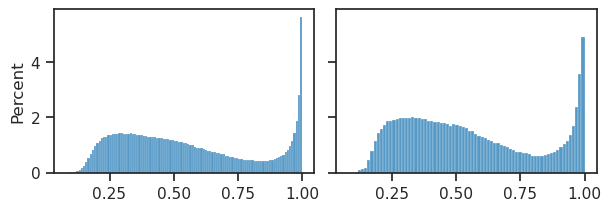

In [7]:
fig, axes = create_figure(1, 2, sharex='all', sharey='all')

sns.histplot(x2p.ravel(), stat='percent', ax=axes[0])
sns.histplot(x2p_bw.ravel(), stat='percent', ax=axes[1])
plt.show()

## color patches: $16 \times 16$

In [8]:
npix = 16

imgs_tensor = {
    k: torch.from_numpy(v).to(device=device)
    for k, v in imgs_color.items()
}
patches = {
    k: xtract_patches(v, npix=npix)
    for k, v in imgs_tensor.items()
}
patches = torch.cat(list(patches.values()))
patches = patches.reshape(-1, 3, npix, npix)
patches = patches.float()

print(patches.shape, patches.dtype)

torch.Size([76880, 3, 16, 16])
torch.float32

### Identify low contrast patches

Bottom $10\%$

In [9]:
q = 0.10

var = np.var(tonp(patches), axis=(1, 2, 3))
var[var == 0] = 1e-10  # prevent div by zero warning

log_var = np.log(var)
thres = np.quantile(log_var, q)
accept = log_var > thres

msg = f"# removed: {(~accept).sum()} ——— # final: {accept.sum()}"
print(msg)

# removed: 7688 ——— # final: 69192

## Save data

### Shuffle

In [10]:
shuffle_inds = np.arange(len(patches))
rng = get_rng(0)
rng.shuffle(shuffle_inds)

### Create save dir

In [11]:
save_dir = pjoin(root, f'Kyoto{npix}')
os.makedirs(save_dir, exist_ok=True)
os.listdir(save_dir)

['patches.npy', 'processed.npy', 'wt_cn.npy', 'wt.npy']

In [12]:
save_dir

'/home/hadi/Datasets/Kyoto/Kyoto16'

### Save

In [13]:
save_obj(
    obj=tonp(patches)[shuffle_inds],
    file_name='patches_color',
    save_dir=save_dir,
    verbose=True,
    mode='npy',
)

[PROGRESS] 'patches_color.npy' saved at
/home/hadi/Datasets/Kyoto/Kyoto16

## color patches: $32 \times 32$

In [14]:
npix = 32

imgs_tensor = {
    k: torch.from_numpy(v).to(device=device)
    for k, v in imgs_color.items()
}
patches = {
    k: xtract_patches(v, npix=npix)
    for k, v in imgs_tensor.items()
}
patches = torch.cat(list(patches.values()))
patches = patches.reshape(-1, 3, npix, npix)
patches = patches.float()

print(patches.shape, patches.dtype)

torch.Size([18600, 3, 32, 32])
torch.float32

### Identify low contrast patches

Bottom $5\%$

In [15]:
q = 0.05

var = np.var(tonp(patches), axis=(1, 2, 3))
var[var == 0] = 1e-10  # prevent div by zero warning

log_var = np.log(var)
thres = np.quantile(log_var, q)
accept = log_var > thres

msg = f"# removed: {(~accept).sum()} ——— # final: {accept.sum()}"
print(msg)

# removed: 930 ——— # final: 17670

## Save data

### Shuffle

In [16]:
shuffle_inds = np.arange(len(patches))
rng = get_rng(0)
rng.shuffle(shuffle_inds)

### Create save dir

In [17]:
save_dir = pjoin(root, f'Kyoto{npix}')
os.makedirs(save_dir, exist_ok=True)
os.listdir(save_dir)

['patches.npy', 'processed.npy', 'wt_cn.npy', 'wt.npy']

In [18]:
save_dir

'/home/hadi/Datasets/Kyoto/Kyoto32'

### Save

In [19]:
save_obj(
    obj=tonp(patches)[shuffle_inds],
    file_name='patches_color',
    save_dir=save_dir,
    verbose=True,
    mode='npy',
)

[PROGRESS] 'patches_color.npy' saved at
/home/hadi/Datasets/Kyoto/Kyoto32

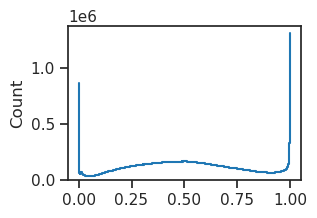

In [20]:
histplot(patches.ravel())
plt.show()